# Lab 3. Basic NN RL methods

## Part 1. Q-network for Cart-Pole

1. Implement DQN and tune it to have stable learning under 1000 episodes. At least try to change
- epsilon decay
- number and a size of the hidden layers in the model
- learning rate (you can use schedulers)
- replay size, and frequency of calling memory replay

2. Implement Target Network

## Part 2. (see below)

## Requirements

- Soft deadline: 19.11 23:59
- Hard dealind: 22.11 23:59

In [79]:
!pip install gymnasium[classic-control] pyvirtualdisplay
!apt-get install -y xvfb python-opengl ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package python-opengl


In [80]:
import matplotlib.pyplot as plt
%matplotlib inline

from IPython import display
from pyvirtualdisplay import Display
d = Display(visible=0, size=(400, 300))
d.start()

def show_state(env, episode=0, step=0, info=""):
    plt.figure(3)
    plt.clf()
    plt.imshow(env.render(mode='rgb_array'))
    plt.title("%s | Eposide: %d | Step: %d %s" % ('Cart-pole-v1', episode, step, info))
    plt.axis('off')

    display.clear_output(wait=True)
    display.display(plt.gcf())


## DQN with experience replay

In [81]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display


# DQN class
class DQN():
    def __init__(self, state_dim, action_dim, hidden_dim=64, alpha=0.003):
        self.model = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=alpha)
        self.losses = []

    def update(self, states, targets):
        states = torch.Tensor(states)
        targets = torch.Tensor(targets)
        y_pred = self.model(states)
        loss = self.criterion(y_pred, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.losses.append(loss.item())

    def predict(self, state):
        with torch.no_grad():
            return self.model(torch.Tensor(state))

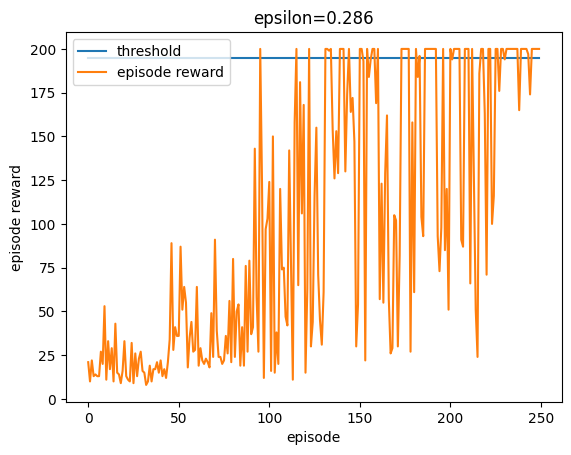

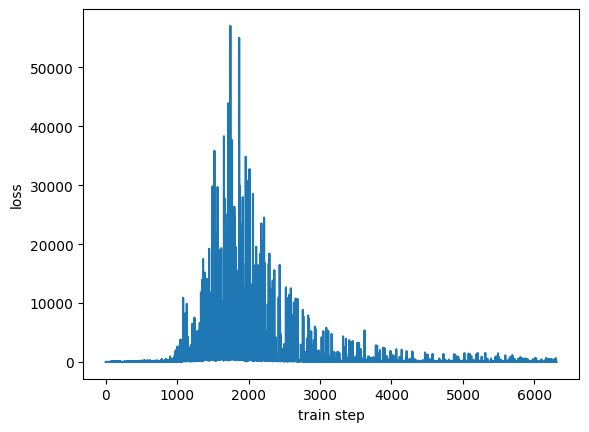

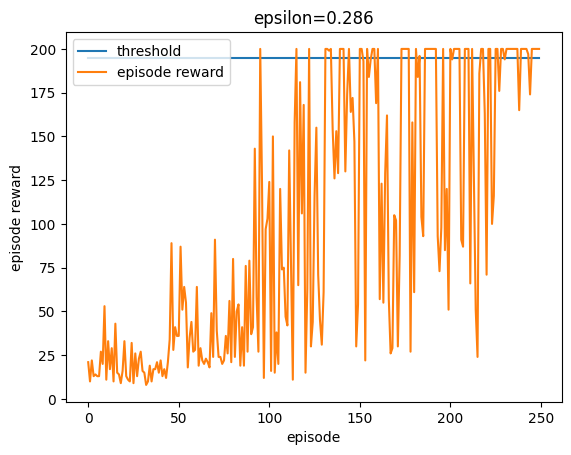

Training done


In [82]:
# Environment setup
env = gym.make('CartPole-v0')
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n


# Hyperparameters
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
gamma = 0.99
alpha = 0.003
hidden_dim = 64
EPISODES_MAX = 250
STEPS_MAX = 200
memory = []
replay_size = 64
batch_size = 32
update_freq = 4  # update network every 4 steps

# Model
model = DQN(n_states, n_actions, hidden_dim)

# Training loop
log_total_reward = []
for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()
    total_reward = 0

    for t in range(STEPS_MAX):
        # Epsilon-greedy action
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            q_values = model.predict(state)
            action = torch.argmax(q_values).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # Store in memory
        memory.append((state, action, reward, next_state, done))
        if len(memory) > 5000:  # max memory size
            memory.pop(0)

        # Sample a batch for training
        if len(memory) >= batch_size and t % update_freq == 0:
            batch = random.sample(memory, batch_size)
            states_b, actions_b, rewards_b, next_states_b, dones_b = zip(*batch)
            states_b = np.array(states_b)
            next_states_b = np.array(next_states_b)

            # Compute targets
            q_next = model.model(torch.Tensor(next_states_b)).detach().numpy()
            targets = model.model(torch.Tensor(states_b)).detach().numpy()
            for i in range(batch_size):
                targets[i, actions_b[i]] = rewards_b[i] + gamma * np.max(q_next[i]) * (not dones_b[i])

            # Update network
            model.update(states_b, targets)

        if done:
            break
        state = next_state

    # Decay epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    log_total_reward.append(total_reward)

    # plotting: loss
    plt.figure(1)
    plt.clf()
    if len(model.losses) > 0:
        plt.plot(range(len(model.losses)), model.losses, label="loss")
        plt.xlabel('train step')
        plt.ylabel('loss')
    display.clear_output(wait=True)
    display.display(plt.gcf())

    # plotting: episode rewards every 50 episodes
    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()
        plt.plot([0, i_episode], [195, 195], label="threshold")
        plt.plot(range(0, i_episode + 1), log_total_reward[:i_episode + 1], label="episode reward")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title(f'epsilon={epsilon:.3f}')
        display.clear_output(wait=True)
        display.display(plt.gcf())

plt.show()
print("Training done")


### Inference

In [83]:
state, _ = env.reset()
total_reward = 0

for step in range(200):
    q_values = model.predict(state)
    action = torch.argmax(q_values).item()
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    if terminated or truncated:
        break

print("Inference reward:", total_reward)


Inference reward: 200.0


## DQN with Target Network

In [116]:
# DQN with Target Network
class DQNTarget(DQN):
    def __init__(self, state_dim, action_dim, hidden_dim=64, alpha=0.005, target_update=10):
        super().__init__(state_dim, action_dim, hidden_dim, alpha)
        self.target_model = copy.deepcopy(self.model)
        self.target_update = target_update
        self.steps = 0

    def update(self, states, targets):
        super().update(states, targets)
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_model.load_state_dict(self.model.state_dict())

    def predict_target(self, states):
        with torch.no_grad():
            return self.target_model(torch.Tensor(states))

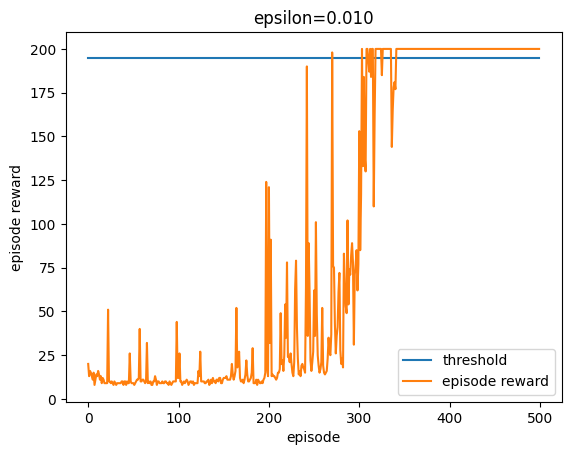

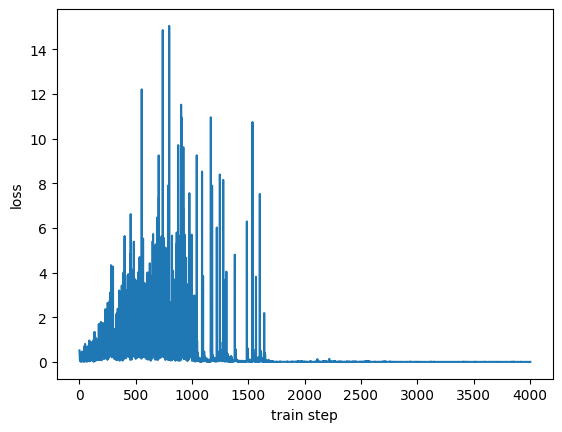

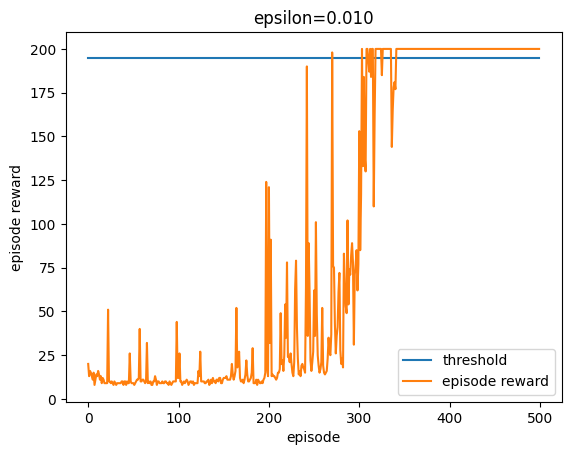

Training done


In [ ]:
# Environment setup
env = gym.make('CartPole-v1')
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n


# Hyperparameters
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.99
gamma = 0.95
alpha = 0.005
hidden_dim = 64
EPISODES_MAX = 500
STEPS_MAX = 200

memory = []
memory_max = 5000
batch_size = 16
update_freq = 12  # network update every 12 steps


# Model
model = DQNTarget(n_states, n_actions, hidden_dim, alpha, target_update=10)


# Training loop
log_total_reward = []

for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()
    total_reward = 0

    for t in range(STEPS_MAX):
        # Epsilon-greedy action
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            q_values = model.predict(state)
            action = torch.argmax(q_values).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # Store in memory
        memory.append((state, action, reward, next_state, done))
        if len(memory) > memory_max:
            memory.pop(0)

        # Sample batch and update network
        if len(memory) >= batch_size and t % update_freq == 0:
            batch = random.sample(memory, batch_size)
            states_b, actions_b, rewards_b, next_states_b, dones_b = zip(*batch)
            states_b = np.array(states_b)
            next_states_b = np.array(next_states_b)

            # Compute target Q-values using target network
            q_next = model.predict_target(next_states_b).numpy()
            targets = model.model(torch.Tensor(states_b)).detach().numpy()
            for i in range(batch_size):
                targets[i, actions_b[i]] = rewards_b[i] + gamma * np.max(q_next[i]) * (not dones_b[i])

            # Update main network
            model.update(states_b, targets)

        if done:
            break
        state = next_state

    # Decay epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    log_total_reward.append(total_reward)

    # Plotting: Reward + Loss
        # Reward plot
    plt.figure(1)
    plt.clf()
    if len(model.losses) > 0:
        plt.plot(range(len(model.losses)), model.losses, label="loss")
        plt.xlabel('train step')
        plt.ylabel('loss')
    display.clear_output(wait=True)
    display.display(plt.gcf())

    # plotting: episode rewards every 50 episodes
    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()
        plt.plot([0, i_episode], [195, 195], label="threshold")
        plt.plot(range(0, i_episode + 1), log_total_reward[:i_episode + 1], label="episode reward")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title(f'epsilon={epsilon:.3f}')
        display.clear_output(wait=True)
        display.display(plt.gcf())

# Plot final
plt.show()
print("Training done")

### Inference

In [118]:
epsilon = 0
state, _ = env.reset()
total_reward = 0

for step in range(200):
    q_values = model.predict(state)
    action = torch.argmax(q_values).item()
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print("Target-network DQN inference reward:", total_reward)


Target-network DQN inference reward: 200.0


## Part 2. Simple Policy Gradient for Cart-Pole

1. Implement [Simple PG](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html) and tune it to have stable learning under 2000 episodes. At least try to change
- epsilon decay
- number and a size of the hidden layers in the model
- learning rate (you can use schedulers)
- batch size

2. Implement Reward-To-Go

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as distributions
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython import display


# Policy Gradient Class
class PG():
    def __init__(self, state_dim, action_dim, hidden_layers=[128,128], alpha=0.01, entropy_beta=0.01):
        layers = []
        last_dim = state_dim
        for h in hidden_layers:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.ReLU())
            last_dim = h
        layers.append(nn.Linear(last_dim, action_dim))
        self.model = nn.Sequential(*layers)

        self.optimizer = optim.Adam(self.model.parameters(), lr=alpha)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=200, gamma=0.9)
        self.entropy_beta = entropy_beta

    def get_policy(self, obs):
        state = torch.FloatTensor(obs)
        logits = self.model(state)
        return distributions.Categorical(logits=logits)

    def get_action(self, obs, epsilon=0.0):
        policy = self.get_policy(obs)
        if np.random.rand() < epsilon:
            return np.random.choice(policy.logits.shape[-1])
        action = policy.sample()
        return action.item()

    def update(self, batch_states, batch_actions, batch_weights):
        self.optimizer.zero_grad()

        states = torch.FloatTensor(batch_states)
        actions = torch.LongTensor(batch_actions)
        weights = torch.FloatTensor(batch_weights)
        weights = (weights - weights.mean()) / (weights.std() + 1e-8)

        logits = self.model(states)
        policy_dist = distributions.Categorical(logits=logits)
        log_probs = policy_dist.log_prob(actions)

        # Entropy bonus for exploration
        entropy = policy_dist.entropy().mean()
        loss = -torch.mean(log_probs * weights) - self.entropy_beta * entropy

        loss.backward()
        self.optimizer.step()
        self.scheduler.step()
        return loss.item()

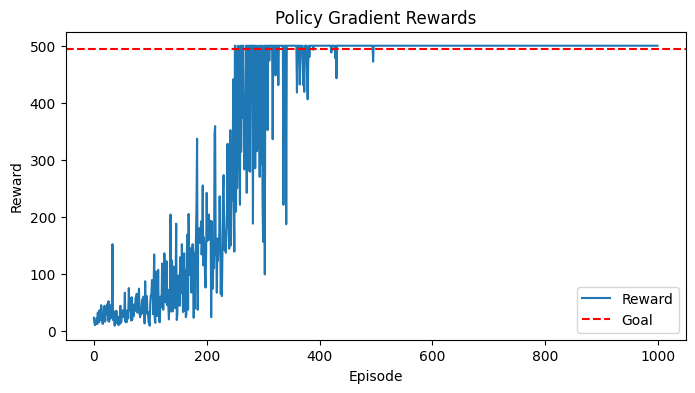

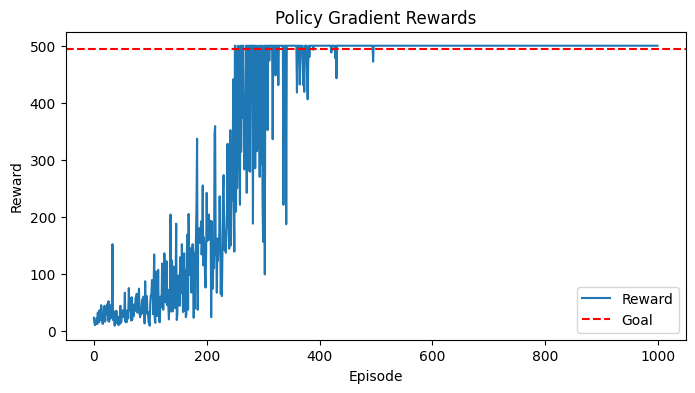

In [99]:
# Environment & Training
env = gym.make('CartPole-v1')
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n

EPISODES_MAX = 1000
STEPS_MAX = 500
BATCH_SIZE = 10   # Update policy every 10 episodes

# Epsilon for exploration
EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995
epsilon = EPS_START

# Create model with larger hidden layers
model_pg = PG(n_states, n_actions, hidden_layers=[128,128], alpha=0.01, entropy_beta=0.01)

log_total_reward = []

batch_states, batch_actions, batch_weights = [], [], []


# Training loop
for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()
    episode_states, episode_actions, episode_rewards = [], [], []

    for t in range(STEPS_MAX):
        action = model_pg.get_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)
        state = next_state

        if done:
            G = sum(episode_rewards)
            batch_states.extend(episode_states)
            batch_actions.extend(episode_actions)
            batch_weights.extend([G]*len(episode_rewards))

            log_total_reward.append(G)
            break

    # Decay epsilon
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # Update policy every BATCH_SIZE episodes
    if (i_episode + 1) % BATCH_SIZE == 0:
        model_pg.update(batch_states, batch_actions, batch_weights)
        batch_states, batch_actions, batch_weights = [], [], []

# Plot rewards
plt.figure(figsize=(8,4))
plt.clf()
plt.plot(log_total_reward, label='Reward')
plt.axhline(495, color='r', linestyle='--', label='Goal')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.title(f'Policy Gradient Rewards')
display.clear_output(wait=True)
display.display(plt.gcf())


### Inference

In [122]:
env = gym.make('CartPole-v1')

state, _ = env.reset()
total_reward = 0
done = False

while not done:
    # Use greedy policy (no exploration)
    action = model_pg.get_action(state, epsilon=0.0)

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    total_reward += reward
    state = next_state

print("\n==========================")
print(f"Final Episode Reward: {total_reward}")
print("==========================")

env.close()



Final Episode Reward: 500.0


In [120]:
test_episodes = 10
env = gym.make('CartPole-v1')

for ep in range(test_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = model_pg.get_action(state, epsilon=0.0)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        state = next_state

    print(f"Episode {ep+1}: Reward = {total_reward}")


Episode 1: Reward = 500.0
Episode 2: Reward = 500.0
Episode 3: Reward = 500.0
Episode 4: Reward = 500.0
Episode 5: Reward = 500.0
Episode 6: Reward = 500.0
Episode 7: Reward = 500.0
Episode 8: Reward = 500.0
Episode 9: Reward = 500.0
Episode 10: Reward = 500.0


## Reward-To-Go


In [133]:
# Reward-to-Go Function
def compute_rewards_to_go(rewards, gamma=0.99):
    n = len(rewards)
    rtg = np.zeros(n)
    future_reward = 0
    for i in reversed(range(n)):
        future_reward = rewards[i] + gamma * future_reward
        rtg[i] = future_reward
    return rtg

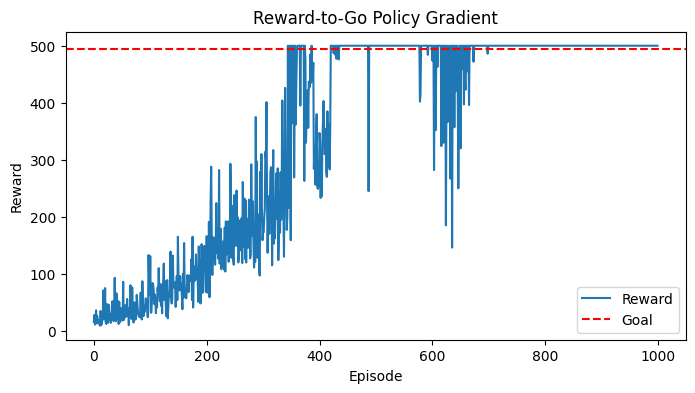

Training complete!


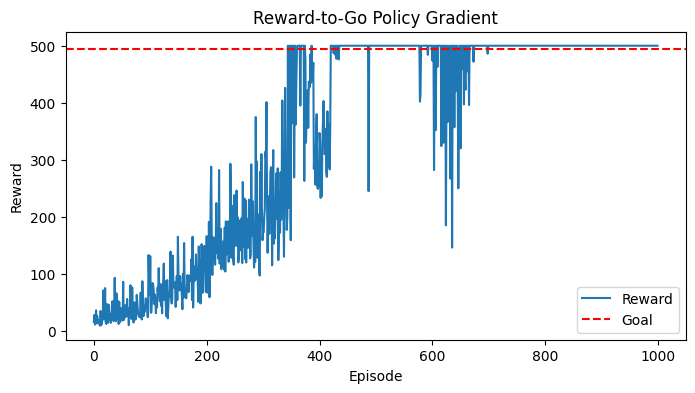

In [137]:
# Environment & Training
env = gym.make('CartPole-v1')
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n

EPISODES_MAX = 1000
STEPS_MAX = 500
BATCH_EPISODES = 15  # Update policy every 15 episodes

model_pg = PG(n_states, n_actions, hidden_layers=[64,64], alpha=0.01, entropy_beta=0.01)

batch_states, batch_actions, batch_weights = [], [], []
log_total_reward = []


# Training loop
for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()
    episode_states, episode_actions, episode_rewards = [], [], []

    for t in range(STEPS_MAX):
        action = model_pg.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)
        state = next_state

        if done:
            # Compute reward-to-go for this episode
            rtg = compute_rewards_to_go(episode_rewards, gamma=0.99)
            batch_states.extend(episode_states)
            batch_actions.extend(episode_actions)
            batch_weights.extend(rtg)

            log_total_reward.append(sum(episode_rewards))
            break

    # Update policy every BATCH_EPISODES
    if (i_episode + 1) % BATCH_EPISODES == 0:
        model_pg.update(batch_states, batch_actions, batch_weights)
        batch_states, batch_actions, batch_weights = [], [], []

# Plot rewards every 50 episodes
plt.figure(figsize=(8,4))
plt.clf()
plt.plot(log_total_reward, label='Reward')
plt.axhline(495, color='r', linestyle='--', label='Goal')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward-to-Go Policy Gradient')
plt.legend()
display.clear_output(wait=True)
display.display(plt.gcf())

print("Training complete!")
env.close()


### Inference

In [135]:
env = gym.make('CartPole-v1')

state, _ = env.reset()
total_reward = 0
done = False

while not done:
    # Greedy action (no exploration)
    action = model_pg.get_action(state)

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    total_reward += reward
    state = next_state

print("\n==========================")
print(f"Final Episode Reward: {total_reward}")
print("==========================")

env.close()


Final Episode Reward: 500.0


In [136]:
test_episodes = 10
env = gym.make('CartPole-v1')

for ep in range(test_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = model_pg.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        state = next_state

    print(f"Test Episode {ep+1}: Reward = {total_reward}")


Test Episode 1: Reward = 500.0
Test Episode 2: Reward = 500.0
Test Episode 3: Reward = 500.0
Test Episode 4: Reward = 500.0
Test Episode 5: Reward = 500.0
Test Episode 6: Reward = 500.0
Test Episode 7: Reward = 500.0
Test Episode 8: Reward = 500.0
Test Episode 9: Reward = 500.0
Test Episode 10: Reward = 500.0
